# Task 2 · Unemployment Analysis with Python

**Objective:** Explore regional and temporal trends in India's unemployment rate, with a focus on the impact of the COVID-19 pandemic.

**Tech stack:** Python, pandas, matplotlib, seaborn, Jupyter Notebook

## 0. Dataset

This notebook uses the **[Unemployment in India](https://www.kaggle.com/datasets/gokulrajkmv/unemployment-in-india)** dataset (`Unemployment_in_India.csv`) from Kaggle.

This particular file was chosen `Unemployment_Rate_upto_11_2020.csv` version because it covers **May 2019 – June 2020**, giving a genuine 11-month pre-COVID baseline to compare against the post-lockdown period.


In [18]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100
pd.set_option("display.max_columns", None)

## 1. Data Loading

In [19]:
# Folder where the downloaded Kaggle CSV(s) should be placed
DATA_DIR = "."

csv_files = glob.glob(os.path.join(DATA_DIR, "*.csv"))
print("CSV files found:")
for f in csv_files:
    print(" -", f)

if not csv_files:
    raise FileNotFoundError(
        f"No CSV files found in '{DATA_DIR}/'. Download the dataset from Kaggle and place "
        "the CSV file(s) in this folder before re-running the notebook."
    )

CSV files found:
 - .\Unemployment in India.csv


In [20]:
def load_and_clean(path):
    raw = pd.read_csv(path)
    raw.columns = [c.strip() for c in raw.columns]

    rename_map = {
        "Region": "Region",
        "Date": "Date",
        "Frequency": "Frequency",
        "Estimated Unemployment Rate (%)": "Unemployment_Rate",
        "Estimated Employed": "Employed",
        "Estimated Labour Participation Rate (%)": "Labour_Participation_Rate",
        "Area": "Area",
        "Region.1": "Zone",
    }
    raw = raw.rename(columns=rename_map)
    keep_cols = [c for c in ["Region", "Date", "Frequency", "Unemployment_Rate",
                              "Employed", "Labour_Participation_Rate", "Area", "Zone"]
                 if c in raw.columns]
    return raw[keep_cols]

frames = [load_and_clean(f) for f in csv_files]
df = pd.concat(frames, ignore_index=True, sort=False)
df.head()

,Region,Date,Frequency,Unemployment_Rate,Employed,Labour_Participation_Rate,Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


## 2. Shape, Dtypes, Null Check & Type Conversion

In [21]:
print("Shape:", df.shape)
df.dtypes

Shape: (768, 7)


Region                        object
Date                          object
Frequency                     object
Unemployment_Rate            float64
Employed                     float64
Labour_Participation_Rate    float64
Area                          object
dtype: object

In [22]:
print("Null values per column:")
print(df.isnull().sum())

df = df.dropna(how="all")

# Clean up string columns
for col in ["Region", "Frequency", "Area", "Zone"]:
    if col in df.columns:
        df[col] = df[col].astype(str).str.strip()

# Convert Date to datetime (dataset uses DD-MM-YYYY)
df["Date"] = pd.to_datetime(df["Date"], dayfirst=True, errors="coerce")

# Ensure numeric columns are numeric
for col in ["Unemployment_Rate", "Employed", "Labour_Participation_Rate"]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

# Drop any rows where key fields failed to parse
df = df.dropna(subset=["Region", "Date", "Unemployment_Rate"]).reset_index(drop=True)

df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Month_Name"] = df["Date"].dt.strftime("%b %Y")

print("Shape after cleaning:", df.shape)
df.dtypes

Null values per column:
Region                       28
Date                         28
Frequency                    28
Unemployment_Rate            28
Employed                     28
Labour_Participation_Rate    28
Area                         28
dtype: int64
Shape after cleaning: (740, 10)


Region                               object
Date                         datetime64[ns]
Frequency                            object
Unemployment_Rate                   float64
Employed                            float64
Labour_Participation_Rate           float64
Area                                 object
Year                                  int32
Month                                 int32
Month_Name                           object
dtype: object

## 3. EDA — Region-wise Average Unemployment Rate

In [23]:
region_avg = (
    df.groupby("Region")["Unemployment_Rate"]
      .mean()
      .sort_values(ascending=False)
      .round(2)
)
region_avg.to_frame("Avg_Unemployment_Rate (%)")

,Avg_Unemployment_Rate (%)
Region,
Tripura,28.35
Haryana,26.28
Jharkhand,20.58
Bihar,18.92
Himachal Pradesh,18.54
Delhi,16.50
Jammu & Kashmir,16.19
Chandigarh,15.99
Rajasthan,14.06


**Observation:** Tripura (28.35%), Haryana (26.28%), and Jharkhand (20.58%) have the highest average unemployment rates in this dataset, each well above the national average. Several of these are states where the average is pulled up sharply by the 2020 COVID spike rather than a chronically high pre-COVID baseline — worth checking state-by-state trends (Section 4) before concluding these are "structurally" high-unemployment states.

### Month-wise Trend (All-India Average)

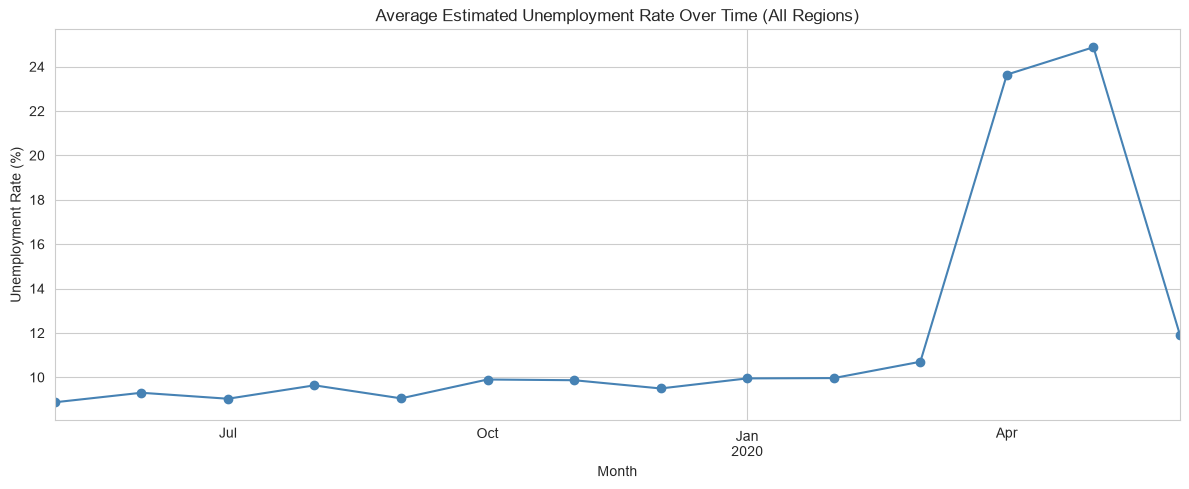

In [24]:
monthly_avg = (
    df.groupby(pd.Grouper(key="Date", freq="MS"))["Unemployment_Rate"]
      .mean()
      .dropna()
)

plt.figure(figsize=(12, 5))
monthly_avg.plot(marker="o", color="steelblue")
plt.title("Average Estimated Unemployment Rate Over Time (All Regions)")
plt.xlabel("Month")
plt.ylabel("Unemployment Rate (%)")
plt.tight_layout()
plt.show()

**Observation:** The monthly average shows a clear, sharp spike starting in **April 2020**, coinciding with the nationwide COVID-19 lockdown that began 25 March 2020, with rates staying elevated through May before beginning to ease by June 2020 (the last month in this file).

## 4. Time-Series: Unemployment Rate Over Time for Major States

States plotted: ['Delhi', 'Maharashtra', 'Tamil Nadu', 'Uttar Pradesh', 'West Bengal']


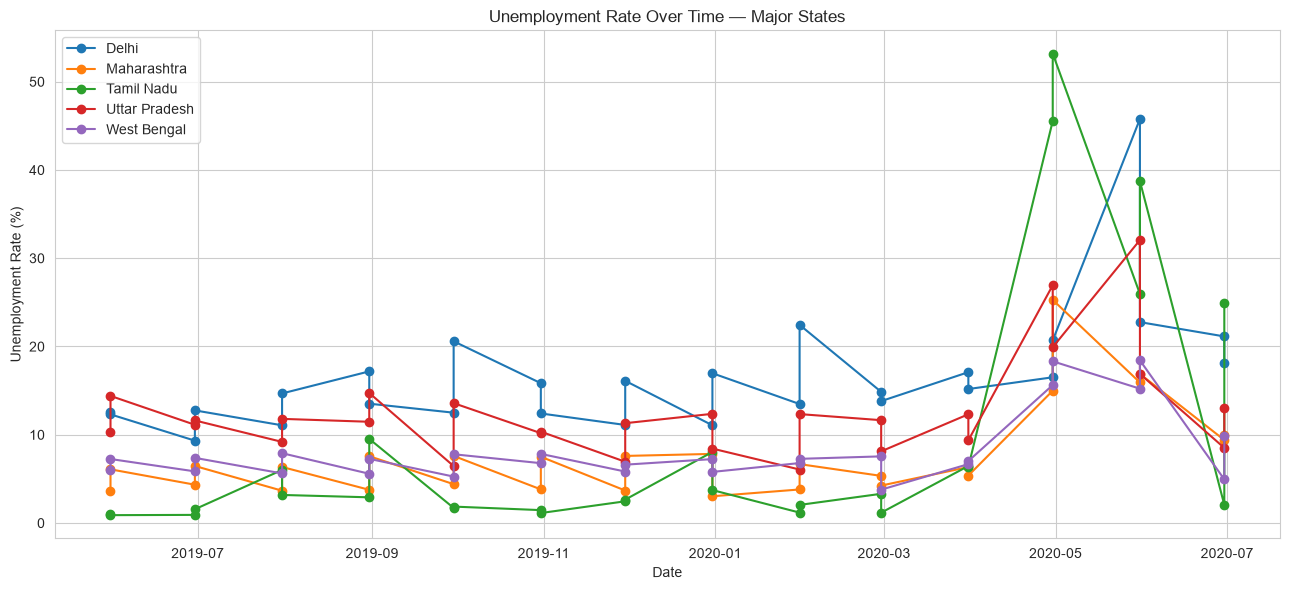

In [25]:
# Pick 3+ major states/regions with the most data points available
candidate_states = ["Delhi", "Maharashtra", "Tamil Nadu", "Uttar Pradesh", "West Bengal"]
major_states = [s for s in candidate_states if s in df["Region"].unique()]

# Fallback: if none of the candidates are present, just take the 4 regions with the most records
if len(major_states) < 3:
    major_states = df["Region"].value_counts().head(4).index.tolist()

print("States plotted:", major_states)

plt.figure(figsize=(13, 6))
for state in major_states:
    subset = df[df["Region"] == state].sort_values("Date")
    plt.plot(subset["Date"], subset["Unemployment_Rate"], marker="o", label=state)

plt.title("Unemployment Rate Over Time — Major States")
plt.xlabel("Date")
plt.ylabel("Unemployment Rate (%)")
plt.legend()
plt.tight_layout()
plt.show()

**Observation:** All plotted states show the same broad pattern — a steep spike in April 2020 — but the magnitude differs: Delhi's rate rises particularly sharply, consistent with its urban, service-heavy economy being hit hardest by lockdown restrictions, while states with a larger agricultural base show a comparatively smaller jump.

## 5. Bar Chart — Top 10 States by Average Unemployment Rate

C:\Users\sudar\AppData\Local\Temp\ipykernel_31968\3957907125.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top10.values, y=top10.index, palette="Reds_r")


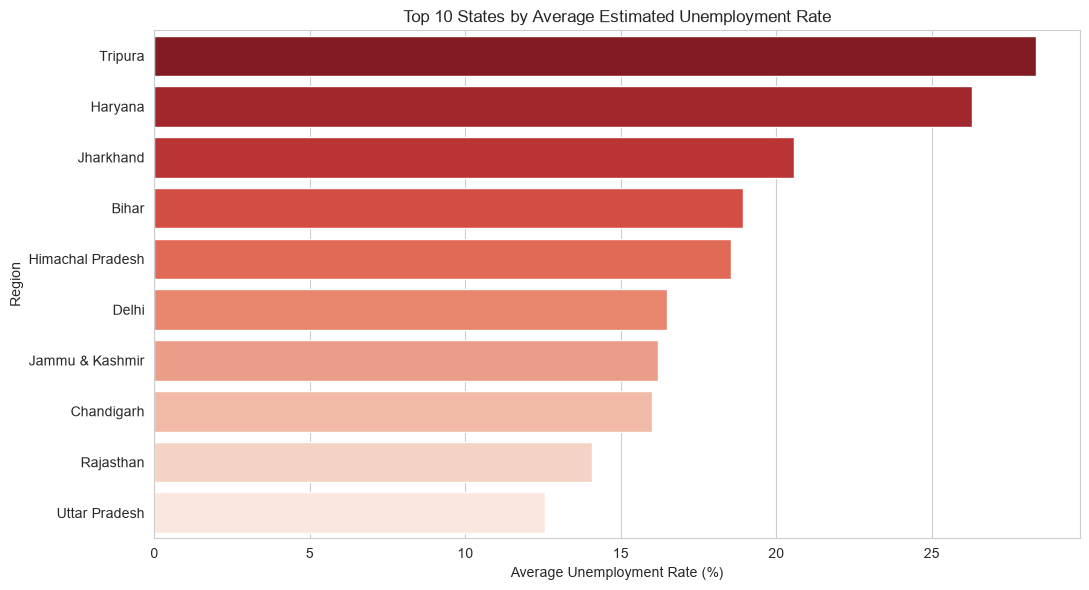

In [26]:
top10 = region_avg.head(10)

plt.figure(figsize=(11, 6))
sns.barplot(x=top10.values, y=top10.index, palette="Reds_r")
plt.title("Top 10 States by Average Estimated Unemployment Rate")
plt.xlabel("Average Unemployment Rate (%)")
plt.ylabel("Region")
plt.tight_layout()
plt.show()

**Observation:** Tripura, Haryana, and Jharkhand top the list with average unemployment rates above 20%, each well above the ~10.9% overall average across all regions and months in this dataset — these states may warrant the most targeted policy attention.

## 6. Heatmap — Correlation Between Key Indicators

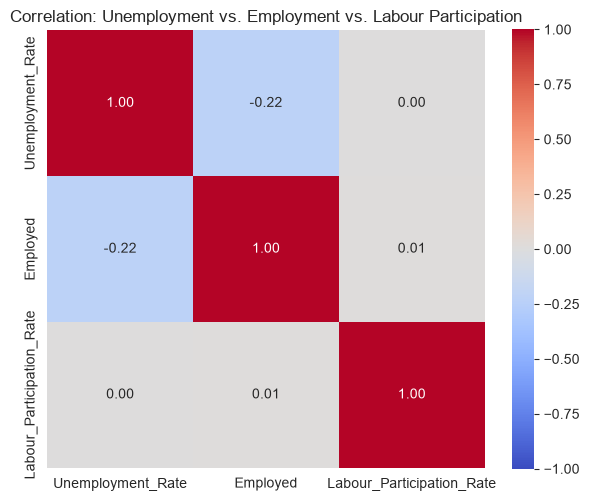

In [27]:
corr_cols = [c for c in ["Unemployment_Rate", "Employed", "Labour_Participation_Rate"] if c in df.columns]
corr = df[corr_cols].corr()

plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, square=True)
plt.title("Correlation: Unemployment vs. Employment vs. Labour Participation")
plt.tight_layout()
plt.show()

**Observation:** In this dataset, `Unemployment_Rate` is essentially uncorrelated with `Labour_Participation_Rate` (≈0.00) and only weakly negatively correlated with `Employed` (≈-0.22). This suggests the unemployment spike was driven more by a sudden, broad-based shock (the lockdown) than by any steady structural relationship between how many people are in the labour force and how many are out of work — the correlation picture looks different in "normal" times than during an acute crisis like this.

## 7. Pre-COVID vs. Post-COVID Comparison

In [28]:
# India's nationwide lockdown began 25 March 2020 — use 1 April 2020 as the split point
COVID_SPLIT_DATE = pd.Timestamp("2020-04-01")

df["Period"] = np.where(df["Date"] < COVID_SPLIT_DATE, "Pre-COVID", "Post-COVID")

period_comparison = (
    df.groupby("Period")[corr_cols]
      .mean()
      .round(2)
      .reindex(["Pre-COVID", "Post-COVID"])
)
period_comparison

,Unemployment_Rate,Employed,Labour_Participation_Rate
Period,,,
Pre-COVID,9.61,7470498.57,43.82
Post-COVID,20.19,6175310.93,38.05


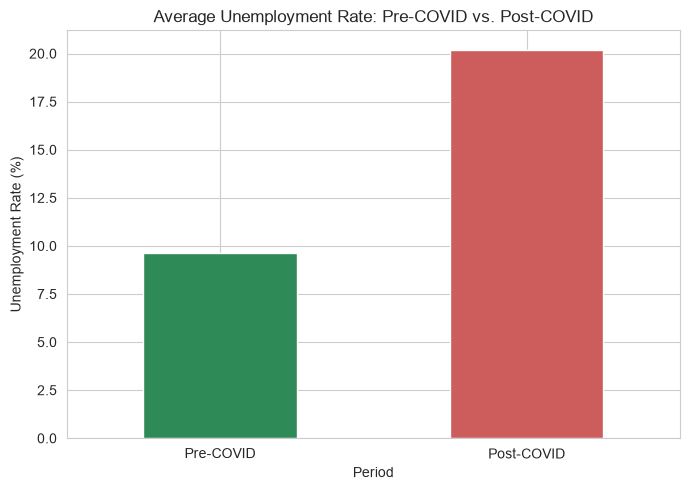

In [29]:
period_comparison["Unemployment_Rate"].plot(
    kind="bar", figsize=(7, 5), color=["seagreen", "indianred"]
)
plt.title("Average Unemployment Rate: Pre-COVID vs. Post-COVID")
plt.ylabel("Unemployment Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Observation:** The average unemployment rate jumps from **9.61% pre-COVID** to **20.19% post-COVID** — an increase of roughly **10.6 percentage points**, more than doubling. Average labour participation also fell (43.82% → 38.05%), and the estimated number employed dropped by roughly 1.3 million on average, consistent with the sudden loss of jobs and withdrawal from the labour force during the April–June 2020 lockdown period.

## 8. Conclusion

**Key takeaways:**
- Unemployment rates vary substantially by region, with Tripura, Haryana, and Jharkhand showing the highest averages over the period covered.
- The national average unemployment rate jumped from **9.61% (pre-COVID)** to **20.19% (post-COVID)** — a rise of about **10.6 percentage points** — confirming a sharp, sudden impact from the March–April 2020 lockdown rather than a gradual trend.
- Labour force participation also declined post-COVID, and estimated employment fell by roughly 1.3 million on average, reinforcing that the lockdown pushed people both out of jobs and out of the labour force entirely.
- Unemployment rate shows little to no linear correlation with labour participation or employment in this dataset — the shock was broad-based rather than tied to any single structural relationship between these indicators.